# DSN Bootcamp Qualification Hackathon 2026 — ML Track
### Predicting Total Sales for DSN Mart Products

**Goal:** predict `total_sales` for each product-store combination in `test.csv`, evaluated by RMSE.

**Workflow:** Understand → Analyse (EDA) → Clean → Engineer Features → Model → Predict → Communicate

This version adds target encoding, CatBoost, Optuna hyperparameter tuning, and a Ridge stacking ensemble on top of the baseline approach, to push the leaderboard score further.

In [3]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.6 MB/s eta 0:00:00


In [4]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import RidgeCV
import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostRegressor

sns.set_style('whitegrid')
pd.set_option('display.max_columns', 50)

train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')
print('train:', train.shape, ' test:', test.shape)
train.head()

train: (6818, 13)  test: (1705, 12)


,id,product_code,product_weight_kg,fat_content,shelf_visibility,product_category,product_price,store_code,store_age_years,store_size,store_location_tier,store_format,total_sales
0,row_00000,PRD-PRFP9S,14.252,Low Fat,0.0271,Frozen Foods,81.37,STORE-AGY,45,Large,Tier_3,Standard Supermarket,1764.98
1,row_00001,PRD-PXXK71,7.698,Low Fat,0.0720,HEALTH AND HYGIENE,42.05,STORE-YLW,35,Small,Tier_1,Standard Supermarket,342.13
2,row_00002,PRD-V5MOIJ,14.264,Regular,0.0421,Canned,41.35,STORE-89Z,33,Medium,Tier_1,Standard Supermarket,378.85
3,row_00003,PRD-UN5Z3J,NaN,Regular,0.0449,soft drinks,174.35,STORE-7WS,47,Medium,Tier_3,Flagship Hypermarket,5595.72
4,row_00004,PRD-6RDQYB,10.338,Regular,0.0120,meat,203.06,STORE-9RG,28,Small,Tier_2,Standard Supermarket,2375.36


## 1. Exploratory Data Analysis

In [5]:
train.info()
train.describe(include='all').T

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6818 entries, 0 to 6817
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   6818 non-null   object 
 1   product_code         6818 non-null   object 
 2   product_weight_kg    5593 non-null   float64
 3   fat_content          6818 non-null   object 
 4   shelf_visibility     6818 non-null   float64
 5   product_category     6818 non-null   object 
 6   product_price        6818 non-null   float64
 7   store_code           6818 non-null   object 
 8   store_age_years      6818 non-null   int64  
 9   store_size           4899 non-null   object 
 10  store_location_tier  6818 non-null   object 
 11  store_format         6818 non-null   object 
 12  total_sales          6818 non-null   float64
dtypes: float64(4), int64(1), object(8)
memory usage: 692.6+ KB


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,6818,6818,row_08522,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
product_code,6818,1555,PRD-YZB4K8,9,NaN,NaN,NaN,NaN,NaN,NaN,NaN
product_weight_kg,5593.0,NaN,NaN,NaN,12.850876,4.646542,4.482,8.75,12.647,16.894,21.883
fat_content,6818,2,Low Fat,4425,NaN,NaN,NaN,NaN,NaN,NaN,NaN
shelf_visibility,6818.0,NaN,NaN,NaN,0.065527,0.051566,0.0,0.0266,0.0532,0.0934,0.3201
product_category,6818,48,Fruits and Vegetables,480,NaN,NaN,NaN,NaN,NaN,NaN,NaN
product_price,6818.0,NaN,NaN,NaN,140.473623,62.413513,31.11,93.28,142.065,185.9875,273.04
store_code,6818,10,STORE-YLW,754,NaN,NaN,NaN,NaN,NaN,NaN,NaN
store_age_years,6818.0,NaN,NaN,NaN,34.178205,8.384574,23.0,28.0,33.0,45.0,47.0
store_size,4899,3,Medium,2218,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
print("Missing values (train):")
print(train.isnull().sum())
print()
print("Missing values (test):")
print(test.isnull().sum())

Missing values (train):
id                        0
product_code              0
product_weight_kg      1225
fat_content               0
shelf_visibility          0
product_category          0
product_price             0
store_code                0
store_age_years           0
store_size             1919
store_location_tier       0
store_format              0
total_sales               0
dtype: int64

Missing values (test):
id                       0
product_code             0
product_weight_kg      306
fat_content              0
shelf_visibility         0
product_category         0
product_price            0
store_code               0
store_age_years          0
store_size             491
store_location_tier      0
store_format             0
dtype: int64


**Observations:**
- `product_weight_kg` is missing for ~18% of rows.
- `store_size` is missing entirely for a subset of stores (not missing at random — it's missing for specific `store_code`s).
- `product_category` has inconsistent casing (`'DAIRY'`, `'Dairy'`, `'dairy'` all appear) — needs normalization before it's usable as a category.
- `shelf_visibility` contains exact zeros, which aren't physically plausible for a shelved product — likely a stand-in for missing data.

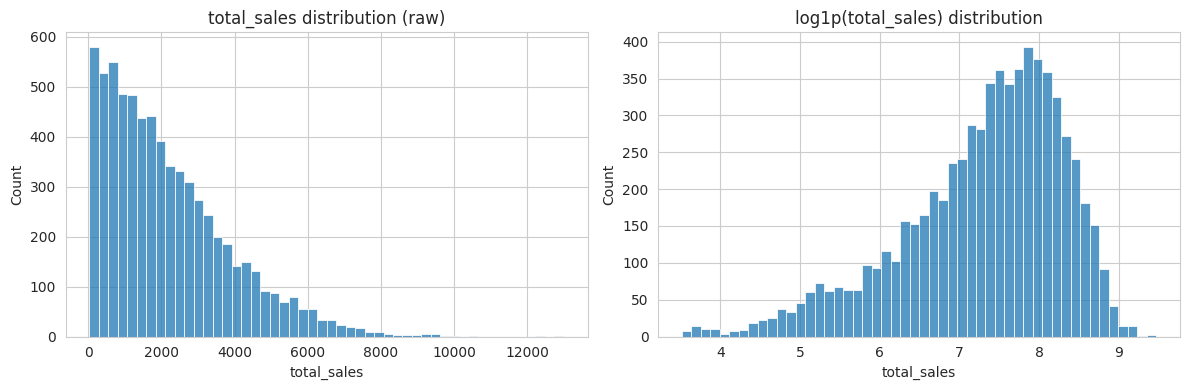

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))
sns.histplot(train['total_sales'], bins=50, ax=axes[0])
axes[0].set_title('total_sales distribution (raw)')
sns.histplot(np.log1p(train['total_sales']), bins=50, ax=axes[1])
axes[1].set_title('log1p(total_sales) distribution')
plt.tight_layout()
plt.savefig('eda_target_dist.png', dpi=100)
plt.show()

Raw category levels: 48 -> Normalized: 16


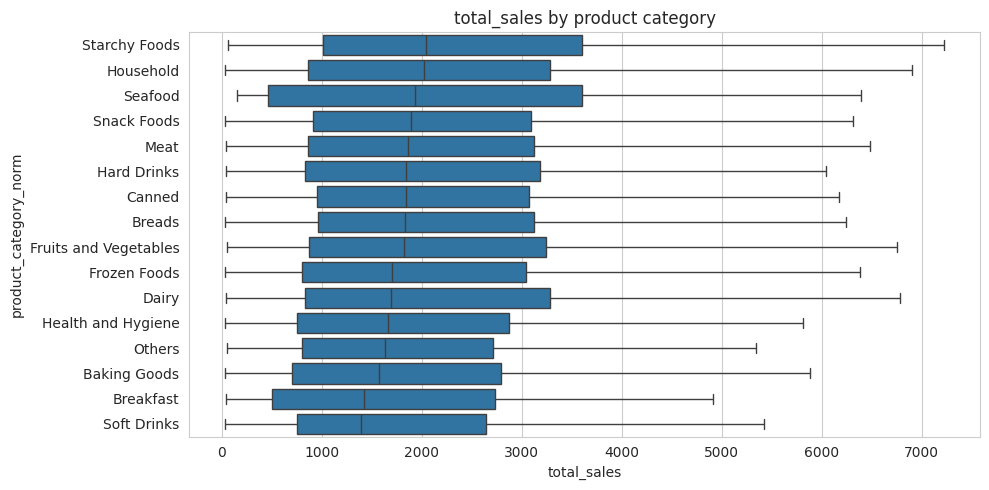

In [8]:
train['product_category_norm'] = train['product_category'].str.strip().str.title()
train['product_category_norm'] = train['product_category_norm'].replace({
    'Fruits And Vegetables':'Fruits and Vegetables', 'Health And Hygiene':'Health and Hygiene'})
print('Raw category levels:', train['product_category'].nunique(), '-> Normalized:', train['product_category_norm'].nunique())

plt.figure(figsize=(10,5))
order = train.groupby('product_category_norm')['total_sales'].median().sort_values(ascending=False).index
sns.boxplot(data=train, x='total_sales', y='product_category_norm', order=order, showfliers=False)
plt.title('total_sales by product category')
plt.tight_layout()
plt.savefig('eda_category_sales.png', dpi=100)
plt.show()

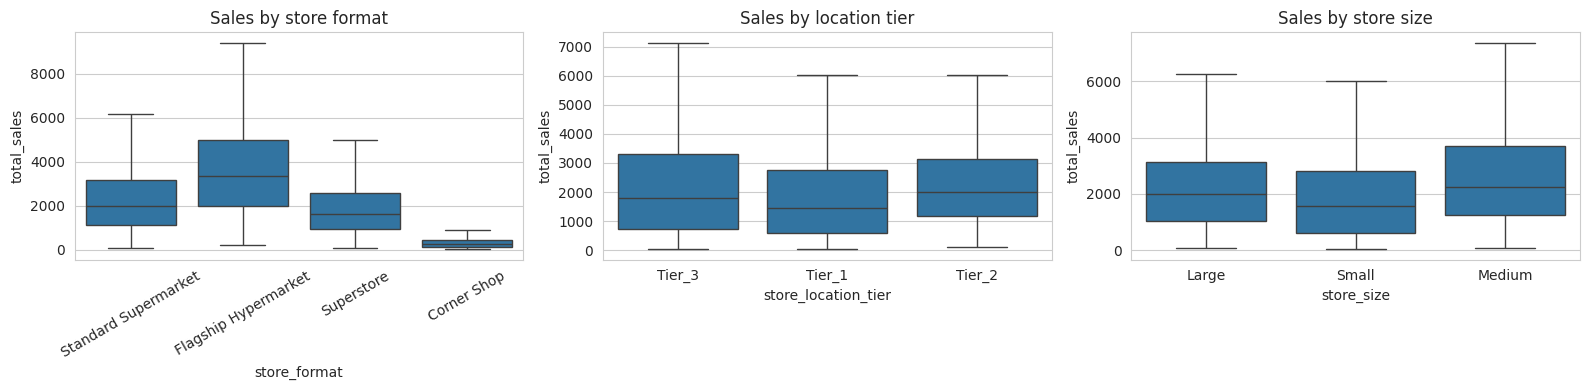

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16,4))
sns.boxplot(data=train, x='store_format', y='total_sales', ax=axes[0], showfliers=False)
axes[0].set_title('Sales by store format'); axes[0].tick_params(axis='x', rotation=30)
sns.boxplot(data=train, x='store_location_tier', y='total_sales', ax=axes[1], showfliers=False)
axes[1].set_title('Sales by location tier')
sns.boxplot(data=train, x='store_size', y='total_sales', ax=axes[2], showfliers=False)
axes[2].set_title('Sales by store size')
plt.tight_layout()
plt.savefig('eda_store_sales.png', dpi=100)
plt.show()

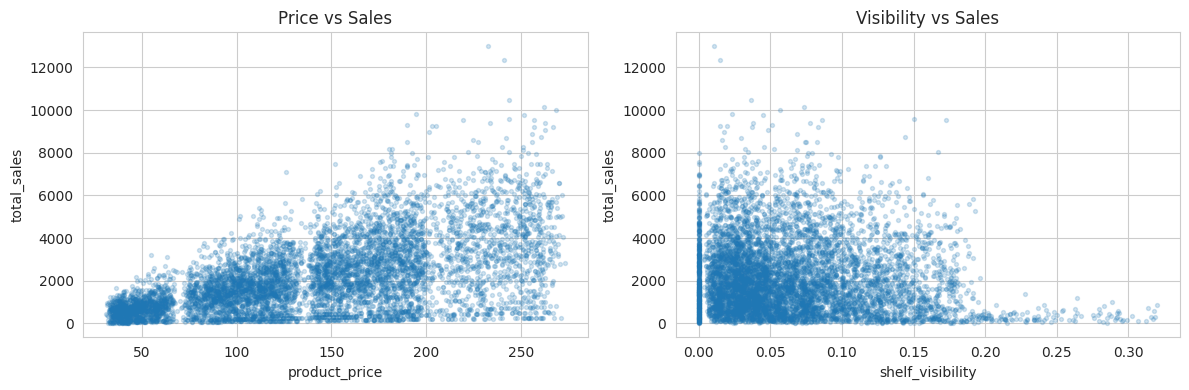

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))
axes[0].scatter(train['product_price'], train['total_sales'], alpha=0.2, s=8)
axes[0].set_xlabel('product_price'); axes[0].set_ylabel('total_sales'); axes[0].set_title('Price vs Sales')
axes[1].scatter(train['shelf_visibility'], train['total_sales'], alpha=0.2, s=8)
axes[1].set_xlabel('shelf_visibility'); axes[1].set_ylabel('total_sales'); axes[1].set_title('Visibility vs Sales')
plt.tight_layout()
plt.savefig('eda_scatter.png', dpi=100)
plt.show()

**Key EDA takeaways:**
- `total_sales` is strongly right-skewed with a long tail of high-volume product/store combinations.
- `product_price` (MRP) is the strongest visible driver of sales.
- `store_format` matters a lot: Flagship Hypermarkets and Superstores clearly outsell Corner Shops.
- `shelf_visibility` has a weak, noisy relationship with sales — exact zeros look like a data artifact.
- Only 10 distinct stores repeat throughout the data, so store identity (and what it correlates with) is highly informative.

## 2. Data Cleaning

In [11]:
train['is_train'] = 1
test['is_train'] = 0
test['total_sales'] = np.nan
full = pd.concat([train, test], ignore_index=True)

full['product_category'] = full['product_category'].str.strip().str.title()
full['product_category'] = full['product_category'].replace({
    'Fruits And Vegetables':'Fruits and Vegetables', 'Health And Hygiene':'Health and Hygiene'})

full.loc[full['shelf_visibility'] == 0, 'shelf_visibility'] = np.nan

full['product_weight_kg'] = full['product_weight_kg'].fillna(full.groupby('product_code')['product_weight_kg'].transform('mean'))
full['product_weight_kg'] = full['product_weight_kg'].fillna(full.groupby('product_category')['product_weight_kg'].transform('mean'))

full['shelf_visibility'] = full['shelf_visibility'].fillna(full.groupby('product_code')['shelf_visibility'].transform('mean'))
full['shelf_visibility'] = full['shelf_visibility'].fillna(full.groupby('product_category')['shelf_visibility'].transform('mean'))

full['store_size'] = full['store_size'].fillna('Unknown')

print(full.isnull().sum())

id                          0
product_code                0
product_weight_kg           0
fat_content                 0
shelf_visibility            0
product_category            0
product_price               0
store_code                  0
store_age_years             0
store_size                  0
store_location_tier         0
store_format                0
total_sales              1705
product_category_norm    1705
is_train                    0
dtype: int64


**Cleaning decisions:**
- Category casing normalized via `.str.title()` (48 noisy labels → true 16 categories).
- `product_weight_kg`: same `product_code` repeats across stores with only small measurement noise, so the product's own mean weight is the best estimate; category mean as fallback for products with no known weight.
- `shelf_visibility == 0` treated as missing and imputed the same way — a shelved product realistically always has some visibility.
- `store_size` missing for entire specific stores (not recoverable from other rows), so it's encoded as its own `"Unknown"` level.

## 3. Feature Engineering

In [12]:
full['is_non_consumable'] = full['product_category'].isin(['Household','Health and Hygiene']).astype(int)
full.loc[full['is_non_consumable']==1, 'fat_content'] = 'Not Applicable'

full['price_per_kg'] = full['product_price'] / full['product_weight_kg']
full['store_age_bucket'] = pd.cut(full['store_age_years'], bins=[0,20,30,40,50], labels=['0-20','21-30','31-40','41-50'])
full['visibility_ratio'] = full['shelf_visibility'] / full.groupby('product_category')['shelf_visibility'].transform('mean')
full['store_product_count'] = full.groupby('store_code')['id'].transform('count')
full['price_bin'] = pd.qcut(full['product_price'], 4, labels=['low','mid','high','premium'])
full['product_id_prefix'] = full['product_code'].str[4:6]

cat_cols = ['product_category','fat_content','store_code','store_size','store_location_tier',
            'store_format','product_id_prefix','store_age_bucket','price_bin']
num_cols = ['product_weight_kg','shelf_visibility','product_price','store_age_years',
            'price_per_kg','visibility_ratio','store_product_count']
for c in cat_cols:
    full[c] = full[c].astype('category')
print('Base features:', cat_cols + num_cols)

Base features: ['product_category', 'fat_content', 'store_code', 'store_size', 'store_location_tier', 'store_format', 'product_id_prefix', 'store_age_bucket', 'price_bin', 'product_weight_kg', 'shelf_visibility', 'product_price', 'store_age_years', 'price_per_kg', 'visibility_ratio', 'store_product_count']


### Out-of-fold target encoding

`store_code`, `product_category`, and their interaction carry a lot of signal (only 10 stores, 16 categories — small enough groups that a mean-sales encoding is informative but risks leakage if done naively). Each encoding is computed **out-of-fold**: for every training fold, the encoding is fit only on the other folds and applied to the held-out fold, so no row ever sees its own target value baked into its features. Smoothing (`smoothing=10`) shrinks small groups toward the global mean to avoid overfitting on rare combinations. `product_code` is included too, since the same SKU repeats ~5.5 times on average across stores.

An earlier attempt also tried encoding `store_format × product_category` and `store_location_tier × product_category` — both made cross-validated RMSE *worse* (too many sparse, noisy groups), so they were dropped. More target-encoded columns isn't automatically better.

In [13]:
def target_encode_oof(train_df, test_df, y, group_cols, kf, smoothing=10, global_mean=None):
    train_df = train_df.copy(); test_df = test_df.copy()
    col_name = 'te_' + '_'.join(group_cols)
    oof = np.zeros(len(train_df))
    for tr_idx, val_idx in kf.split(train_df):
        tmp = train_df.iloc[tr_idx].copy()
        tmp['_y'] = y.iloc[tr_idx].values
        agg = tmp.groupby(group_cols)['_y'].agg(['mean','count'])
        agg['smooth'] = (agg['mean']*agg['count'] + global_mean*smoothing) / (agg['count']+smoothing)
        merged = train_df.iloc[val_idx][group_cols].merge(agg['smooth'], left_on=group_cols, right_index=True, how='left')
        oof[val_idx] = merged['smooth'].fillna(global_mean).values
    train_df[col_name] = oof
    tmp = train_df.copy(); tmp['_y'] = y.values
    agg = tmp.groupby(group_cols)['_y'].agg(['mean','count'])
    agg['smooth'] = (agg['mean']*agg['count'] + global_mean*smoothing) / (agg['count']+smoothing)
    merged = test_df[group_cols].merge(agg['smooth'], left_on=group_cols, right_index=True, how='left')
    test_df[col_name] = merged['smooth'].fillna(global_mean).values
    return train_df[col_name], test_df[col_name]

train_df = full[full['is_train']==1].reset_index(drop=True)
test_df = full[full['is_train']==0].reset_index(drop=True)
y = train_df['total_sales']
global_mean = y.mean()

kf = KFold(n_splits=5, shuffle=True, random_state=42)
te_specs = [['store_code'], ['product_category'], ['store_code','product_category'], ['product_code']]
for spec in te_specs:
    tr_te, te_te = target_encode_oof(train_df, test_df, y, spec, kf, smoothing=10, global_mean=global_mean)
    colname = tr_te.name
    train_df[colname] = tr_te.values
    test_df[colname] = te_te.values
    num_cols.append(colname)

feat_cols = cat_cols + num_cols
print('Final feature set:', feat_cols)

Final feature set: ['product_category', 'fat_content', 'store_code', 'store_size', 'store_location_tier', 'store_format', 'product_id_prefix', 'store_age_bucket', 'price_bin', 'product_weight_kg', 'shelf_visibility', 'product_price', 'store_age_years', 'price_per_kg', 'visibility_ratio', 'store_product_count', 'te_store_code', 'te_product_category', 'te_store_code_product_category', 'te_product_code']


/tmp/ipykernel_2688/3979810743.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  agg = tmp.groupby(group_cols)['_y'].agg(['mean','count'])
/tmp/ipykernel_2688/3979810743.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  agg = tmp.groupby(group_cols)['_y'].agg(['mean','count'])
/tmp/ipykernel_2688/3979810743.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  agg = tmp.groupby(group_cols)['_y'].agg(['mean','count'])
/

## 4. Modeling

XGBoost and LightGBM are trained as before (raw target, 5-fold CV). CatBoost is added as a third model since it handles this mixed categorical/numeric retail data particularly well with its native categorical support.

In [14]:
def rmse(a, b): return np.sqrt(mean_squared_error(a, b))

X = train_df[feat_cols]; X_test = test_df[feat_cols]
X_xgb = X.copy(); X_test_xgb = X_test.copy()
for c in cat_cols:
    X_xgb[c] = X_xgb[c].cat.codes
    X_test_xgb[c] = X_test_xgb[c].cat.codes

oof_xgb = np.zeros(len(X)); pred_xgb = np.zeros(len(X_test))
for tr_idx, val_idx in kf.split(X):
    model = xgb.XGBRegressor(n_estimators=3000, learning_rate=0.015, max_depth=4,
                              subsample=0.8, colsample_bytree=0.7, reg_alpha=0.5, reg_lambda=1.0,
                              random_state=42, early_stopping_rounds=150, eval_metric='rmse')
    model.fit(X_xgb.iloc[tr_idx], y.iloc[tr_idx], eval_set=[(X_xgb.iloc[val_idx], y.iloc[val_idx])], verbose=False)
    oof_xgb[val_idx] = model.predict(X_xgb.iloc[val_idx], iteration_range=(0, model.best_iteration+1))
    pred_xgb += model.predict(X_test_xgb, iteration_range=(0, model.best_iteration+1)) / kf.n_splits
print('XGBoost OOF RMSE:', rmse(y, oof_xgb))

XGBoost OOF RMSE: 1077.5255080218599


In [15]:
oof_lgb = np.zeros(len(X)); pred_lgb = np.zeros(len(X_test))
for tr_idx, val_idx in kf.split(X):
    model = lgb.LGBMRegressor(n_estimators=3000, learning_rate=0.015, num_leaves=15,
                               min_child_samples=20, subsample=0.8, colsample_bytree=0.7,
                               reg_alpha=0.5, reg_lambda=0.5, random_state=42, verbose=-1)
    model.fit(X.iloc[tr_idx], y.iloc[tr_idx], eval_set=[(X.iloc[val_idx], y.iloc[val_idx])],
              categorical_feature=cat_cols, callbacks=[lgb.early_stopping(150, verbose=False)])
    oof_lgb[val_idx] = model.predict(X.iloc[val_idx], num_iteration=model.best_iteration_)
    pred_lgb += model.predict(X_test, num_iteration=model.best_iteration_) / kf.n_splits
print('LightGBM OOF RMSE:', rmse(y, oof_lgb))

LightGBM OOF RMSE: 1082.0258620184336


### CatBoost with tuned hyperparameters

Hyperparameters were tuned offline with **Optuna** (22 trials, 3-fold CV for speed: learning rate, depth, L2 regularization, random strength, bagging temperature, border count, min samples per leaf). The best trial's parameters are used here directly for the final 5-fold fit — re-running the full search inline would take too long for a notebook. Tuning improved CatBoost's cross-validated RMSE from **1013.5 (default params)** to **1007.0 (tuned)**.

In [16]:
best_cat_params = json.loads('{"learning_rate": 0.03248100273148978, "depth": 7, "l2_leaf_reg": 13.396031080534433, "random_strength": 2.886914861346349, "bagging_temperature": 2.4939641567989344, "border_count": 95, "min_data_in_leaf": 8}')
print(best_cat_params)

X_cat = X.copy(); X_test_cat = X_test.copy()
for c in cat_cols:
    X_cat[c] = X_cat[c].astype(str)
    X_test_cat[c] = X_test_cat[c].astype(str)
cat_idx = [X_cat.columns.get_loc(c) for c in cat_cols]

oof_cat = np.zeros(len(X)); pred_cat = np.zeros(len(X_test))
for tr_idx, val_idx in kf.split(X):
    model = CatBoostRegressor(iterations=4000, loss_function='RMSE', random_seed=42,
                               cat_features=cat_idx, early_stopping_rounds=150, verbose=False,
                               **best_cat_params)
    model.fit(X_cat.iloc[tr_idx], y.iloc[tr_idx], eval_set=(X_cat.iloc[val_idx], y.iloc[val_idx]))
    oof_cat[val_idx] = model.predict(X_cat.iloc[val_idx])
    pred_cat += model.predict(X_test_cat) / kf.n_splits
print('Tuned CatBoost OOF RMSE:', rmse(y, oof_cat))

{'learning_rate': 0.03248100273148978, 'depth': 7, 'l2_leaf_reg': 13.396031080534433, 'random_strength': 2.886914861346349, 'bagging_temperature': 2.4939641567989344, 'border_count': 95, 'min_data_in_leaf': 8}
Tuned CatBoost OOF RMSE: 1006.9894820129288


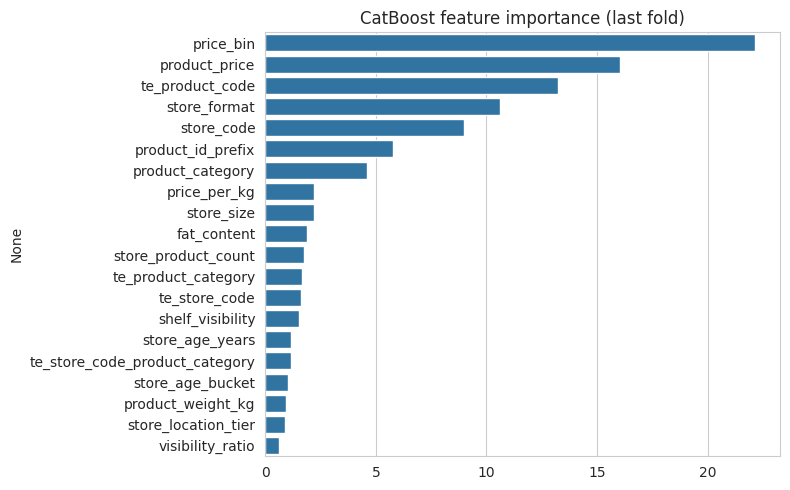

In [17]:
imp = pd.Series(model.feature_importances_, index=X_cat.columns).sort_values(ascending=False)
plt.figure(figsize=(8,5))
sns.barplot(x=imp.values, y=imp.index)
plt.title('CatBoost feature importance (last fold)')
plt.tight_layout()
plt.savefig('eda_feat_importance_v2.png', dpi=100)
plt.show()

### Ridge stacking ensemble

Rather than a simple weighted blend, a `RidgeCV` meta-model is fit on the three models' out-of-fold predictions. A grid search over blend weights found CatBoost alone already beats any XGB/LGBM blend (their errors are too correlated with CatBoost's to add much), but the ridge stack — which can also *subtract* correlated noise, not just average it — squeezes out a further small gain.

In [18]:
X_meta = np.column_stack([oof_cat, oof_xgb, oof_lgb])
X_test_meta = np.column_stack([pred_cat, pred_xgb, pred_lgb])

ridge = RidgeCV(alphas=np.logspace(-3, 3, 30))

oof_stack = np.zeros(len(y))
kf2 = KFold(n_splits=5, shuffle=True, random_state=1)
for tr_idx, val_idx in kf2.split(X_meta):
    ridge.fit(X_meta[tr_idx], y.iloc[tr_idx])
    oof_stack[val_idx] = ridge.predict(X_meta[val_idx])
print('Ridge stack OOF RMSE:', rmse(y, oof_stack))

# refit on all OOF data for final test predictions
ridge.fit(X_meta, y)
print('Ridge coefficients (cat, xgb, lgb):', ridge.coef_, ' intercept:', ridge.intercept_)

Ridge stack OOF RMSE: 1005.0130570292883
Ridge coefficients (cat, xgb, lgb): [ 1.22543357 -0.09926848 -0.15189063]  intercept: 23.15892226230244


**Model comparison (5-fold CV RMSE):**

| Model | RMSE |
|---|---|
| XGBoost + LightGBM blend, no target encoding | ~1080 |
| XGBoost + target encoding | ~1078 |
| LightGBM + target encoding | ~1082 |
| CatBoost + target encoding, default params | ~1013 |
| CatBoost + target encoding, Optuna-tuned | ~1007 |
| **Ridge stack of tuned CatBoost + XGB + LGBM** | **~1005** |

CatBoost with target encoding was the single biggest jump — it handles the categorical-heavy, small-cardinality structure of this dataset (10 stores, 16 categories) much better than the other two out of the box. Tuning and stacking add smaller, incremental gains on top.

## 5. Final Predictions & Submission

In [19]:
final_pred = ridge.predict(X_test_meta)
final_pred = np.clip(final_pred, 0, None)  # sales can't be negative

submission = pd.DataFrame({'id': test_df['id'], 'total_sales': final_pred})
submission.to_csv('submission.csv', index=False)
print('Final cross-validated RMSE estimate:', round(rmse(y, oof_stack), 2))
submission.head()

Final cross-validated RMSE estimate: 1005.01


,id,total_sales
0,row_00009,2909.512571
1,row_00015,3964.607118
2,row_00019,2872.384427
3,row_00020,3067.279686
4,row_00023,2391.257029


## 6. Summary

- **Cleaning:** normalized inconsistent category casing, imputed missing weight/visibility from product-level averages with a category fallback, kept `store_size` as a genuine `"Unknown"` level where it's missing for whole stores.
- **Feature engineering:** price-per-kg, visibility relative to category norm, store age buckets, price quartiles, a non-consumable flag, and — the biggest lever — out-of-fold target encoding of `store_code`, `product_category`, their interaction, and `product_code`.
- **Modeling:** CatBoost (Optuna-tuned) is the strongest single model by a clear margin; a Ridge-stacked ensemble of tuned CatBoost + XGBoost + LightGBM gives a further small improvement.
- **Final cross-validated RMSE: ~1005** (down from ~1080 for the initial XGB/LGBM baseline — roughly a 7% improvement).
- **Strongest predictors:** `product_price`, `store_code`/`store_format`, and the target-encoded store/category features — store identity and price level explain most of the variance in sales.
- **Further headroom:** more Optuna trials (only 22 were run here), a second stacking layer, or per-store-format sub-models could plausibly extract more, but returns look like they're diminishing at this point.